# IIC 2440 – Procesamiento de Datos Masivos
## Tarea 1 — Parte 2: Analítica y MapReduce

---
## Imports y configuración

In [22]:
import os
import sys
import math
import collections
import csv
import functools
import itertools
import re
import unicodedata
from datetime import datetime, timedelta

# Agrega la carpeta del proyecto al path para importar utilidades.py
sys.path.insert(0, os.path.dirname(os.path.abspath("utilidades.py")))
from utilidades import (
    leer_warehouse, leer_parquet_simple,
    cargar_dim_region, cargar_dim_source,
    tokenizar, normalizar, STOPWORDS,
    mapreduce, shuffle_and_sort, reduce_list,
    sumar, top_k, contar_tokens_por_clave
)

# RUTAS
WAREHOUSE_PATH  = "data\\warehouse\\fact_news" # carpeta raíz de fact_news
DIM_REGION_PATH = "data\\warehouse\\dim_region\\dim_region.parquet"
DIM_SOURCE_PATH = "data\\warehouse\\dim_source\\dim_source.parquet"
DIM_DATE_PATH   = "data\\warehouse\\dim_date\\dim_date.parquet"


---
## Exploración rápida del warehouse

In [23]:
# Cargar dimensiones
dim_region = cargar_dim_region(DIM_REGION_PATH)
dim_source = cargar_dim_source(DIM_SOURCE_PATH)

print(f"Regiones disponibles ({len(dim_region)}):")
for sk, nombre in sorted(dim_region.items()):
    print(f"  {sk:3d} → {nombre}")

print(f"\nFuentes disponibles: {len(dim_source)}")


Regiones disponibles (17):
    1 → Antofagasta
    2 → Arica y Parinacota
    3 → Atacama
    4 → Aysén
    5 → Biobío
    6 → Coquimbo
    7 → Desconocida
    8 → La Araucanía
    9 → Los Lagos
   10 → Los Ríos
   11 → Magallanes
   12 → Maule
   13 → Metropolitana
   14 → O'Higgins
   15 → Tarapacá
   16 → Valparaíso
   17 → Ñuble

Fuentes disponibles: 106


In [24]:
# Conteo rápido de artículos por año-mes
import pyarrow.parquet as pq

conteo_particiones = {}
for entry in sorted(os.listdir(WAREHOUSE_PATH)):
    if not entry.startswith("year="): continue
    anio = int(entry.split("=")[1])
    year_path = os.path.join(WAREHOUSE_PATH, entry)
    for sub in sorted(os.listdir(year_path)):
        if not sub.startswith("month="): continue
        mes = int(sub.split("=")[1])
        month_path = os.path.join(year_path, sub)
        n = 0
        for f in os.listdir(month_path):
            if not f.endswith(".parquet"): continue
            # Leer solo metadata (no carga datos a memoria)
            meta = pq.read_metadata(os.path.join(month_path, f))
            n += meta.num_rows
        conteo_particiones[f"{anio}-{mes:02d}"] = n

total = sum(conteo_particiones.values())
print(f"Total artículos en warehouse: {total:,}")
print("\nDistribución por año-mes:")
for ym, n in sorted(conteo_particiones.items()):
    print(f"  {ym}: {n:7,}")

Total artículos en warehouse: 1,467,309

Distribución por año-mes:
  2023-01:  39,658
  2023-02:  36,400
  2023-03:  42,342
  2023-04:  37,246
  2023-05:  40,131
  2023-06:  38,436
  2023-07:  31,844
  2023-08:  33,731
  2023-09:  31,827
  2023-10:  40,715
  2023-11:  41,881
  2023-12:  39,231
  2024-01:  44,001
  2024-02:  41,674
  2024-03:  40,609
  2024-04:  43,274
  2024-05:  42,486
  2024-06:  39,736
  2024-07:  44,932
  2024-08:  41,272
  2024-09:  39,929
  2024-10:  46,286
  2024-11:  38,478
  2024-12:  36,824
  2025-01:  38,738
  2025-02:  35,293
  2025-03:  38,588
  2025-04:  43,162
  2025-05:  43,890
  2025-06:  41,502
  2025-07:  42,681
  2025-08:  42,145
  2025-09:  43,992
  2025-10:  50,600
  2025-11:  47,866
  2025-12:  45,909


---
## 2.1: Top-K términos mensuales
Los 20 términos más frecuentes por año-mes.


In [25]:
# == Pasada MapReduce ===
# Map: artículo → tokens de (title + body), clave = "año-mes"
# Combine: acumula conteos localmente por (año-mes, palabra) sin emitir pares (clave, 1)
# Reduce: resultado final es dict {(año-mes, palabra): frecuencia_total}

# En lugar de map → chain → shuffle → reduce:
freq_ym_palabra = contar_tokens_por_clave(
    leer_warehouse(WAREHOUSE_PATH, columnas=["year", "month", "title", "body"]),
    clave_fn=lambda a: f"{a['year']}-{a['month']:02d}",
    texto_fn=lambda a: (a.get("title") or "") + " " + (a.get("body") or "")
    )

print(f"Pares únicos (año-mes, palabra): {len(freq_ym_palabra):,}")


Pares únicos (año-mes, palabra): 4,971,900


In [26]:
# Top-20 por mes
# Reagrupar por año-mes

freq_por_mes = collections.defaultdict(list)
for (ym, palabra), cnt in freq_ym_palabra.items():
    freq_por_mes[ym].append((palabra, cnt))

# Top-20 por mes
topk_mensual = {
    ym: sorted(pares, key=lambda x: x[1], reverse=True)[:20]
    for ym, pares in freq_por_mes.items()
}

# Mostrar resultado
print("Formato: año-mes, término, frecuencia\n")
for ym in sorted(topk_mensual.keys()):
    print(f"== {ym} ==")
    for palabra, cnt in topk_mensual[ym][:5]: # mostramos los 5 primeros
        print(f"   {ym}, {palabra}, {cnt}")
    print()

Formato: año-mes, término, frecuencia

== 2023-01 ==
   2023-01, personas, 18142
   2023-01, gobierno, 16906
   2023-01, pais, 16299
   2023-01, nacional, 15568
   2023-01, presidente, 15025

== 2023-02 ==
   2023-02, personas, 16409
   2023-02, pais, 14387
   2023-02, incendios, 13447
   2023-02, nacional, 12471
   2023-02, vina, 11572

== 2023-03 ==
   2023-03, personas, 17424
   2023-03, gobierno, 16418
   2023-03, pais, 15471
   2023-03, nacional, 14275
   2023-03, presidente, 13495

== 2023-04 ==
   2023-04, personas, 15835
   2023-04, pais, 14379
   2023-04, nacional, 13230
   2023-04, estado, 12441
   2023-04, gobierno, 12373

== 2023-05 ==
   2023-05, personas, 17629
   2023-05, pais, 15036
   2023-05, gobierno, 13934
   2023-05, nacional, 13488
   2023-05, estado, 12956

== 2023-06 ==
   2023-06, personas, 16131
   2023-06, pais, 14840
   2023-06, presidente, 13210
   2023-06, estado, 12934
   2023-06, nacional, 12248

== 2023-07 ==
   2023-07, estado, 12033
   2023-07, person

In [27]:
# Guardar resultado en CSV
os.makedirs("resultados", exist_ok=True)
with open("resultados/2_1_topk_mensual.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["anio_mes", "termino", "frecuencia"])
    for ym in sorted(topk_mensual.keys()):
        for palabra, cnt in topk_mensual[ym]:
            writer.writerow([ym, palabra, cnt])

print("Guardado en resultados/2_1_topk_mensual.csv")


Guardado en resultados/2_1_topk_mensual.csv


---
## 2.2: Distribución de palabras por región

Para cada par `(región, término)`: ocurrencias regionales, ocurrencias globales y razón (regional / global).

In [28]:
K = 50

# == Pasada 1: frecuencias globales ==
# Map: artículo → tokens de (title + body), clave fija = "global"
# Combine: acumula conteos por ("global", palabra) sin emitir pares (clave, 1)
# Reduce: resultado es dict {("global", palabra): frecuencia_total}

freq_global = contar_tokens_por_clave(
    leer_warehouse(WAREHOUSE_PATH, columnas=["title", "body"]), # solo columnas necesarias
    clave_fn=lambda a: "global", # clave única → agrupa todas las palabras sin distinción de artículo
    texto_fn=lambda a: (a.get("title") or "") + " " + (a.get("body") or "")
)

# contar_tokens_por_clave -> {("global", palabra): cnt}
freq_global = {palabra: cnt for (_, palabra), cnt in freq_global.items()}

# descartar palabras con frecuencia global < K
vocab_filtrado = {p: c for p, c in freq_global.items() if c >= K}
print(f"Vocabulario con freq >= {K}: {len(vocab_filtrado):,} palabras")

Vocabulario con freq >= 50: 100,578 palabras


In [29]:
# == Pasada 2: frecuencias regionales ==
# Map: artículo → tokens de (title + body), clave = region_sk, artículos con región "Desconocida" se excluyen (clave_fn retorna None)
# Combine: acumula conteos por (region_sk, palabra)
# Post: se descartan palabras fuera del vocab_filtrado para consistencia con pasada 1

# Cargar SKs de regiones válidas (excluye "Desconocida")
dim_reg_completo = leer_parquet_simple(DIM_REGION_PATH)
regiones_conocidas = {f["region_sk"] for f in dim_reg_completo if f["is_known_region"]}

freq_regional = contar_tokens_por_clave(
    leer_warehouse(WAREHOUSE_PATH, columnas=["region_sk", "title", "body"]),
    clave_fn=lambda a: a.get("region_sk") if a.get("region_sk") in regiones_conocidas else None,
    texto_fn=lambda a: (a.get("title") or "") + " " + (a.get("body") or "")
)
# Filtrar palabras que no superan el umbral global (mismo vocab que pasada 1)
freq_regional = {(reg, pal): cnt for (reg, pal), cnt in freq_regional.items() if pal in vocab_filtrado}

print(f"Pares únicos (región, palabra): {len(freq_regional):,}")

Pares únicos (región, palabra): 1,118,753


In [30]:
# == Post-proceso: calcular razón regional/global ==
resultados_22 = []
for (region_sk, palabra), freq_reg in freq_regional.items():
    freq_glob = vocab_filtrado.get(palabra, 1)
    razon = freq_reg / freq_glob
    resultados_22.append({
        "region_sk": region_sk,
        "region": dim_region.get(region_sk, "?"),
        "palabra": palabra,
        "freq_regional": freq_reg,
        "freq_global": freq_glob,
        "razon": round(razon, 6),
    })

# Ordenar por razón desc para ver palabras distintivas por región
resultados_22.sort(key=lambda x: x["razon"], reverse=True)

print("Top 5 palabras con mayor concentración regional:")
for r in resultados_22[:15]:
    print(f"  {r['region']:25s} | {r['palabra']:20s} | reg={r['freq_regional']:6d} | glob={r['freq_global']:8d} | razón={r['razon']:.4f}")


Top 5 palabras con mayor concentración regional:
  Metropolitana             | bulliari             | reg=   212 | glob=     212 | razón=1.0000
  Metropolitana             | paracido             | reg=   188 | glob=     188 | razón=1.0000
  Metropolitana             | ciclorecrevia        | reg=   292 | glob=     292 | razón=1.0000
  Metropolitana             | canopys              | reg=    89 | glob=      89 | razón=1.0000
  Metropolitana             | kellendonk           | reg=   189 | glob=     189 | razón=1.0000
  Metropolitana             | maratoneando         | reg=   189 | glob=     189 | razón=1.0000
  Metropolitana             | flipos               | reg=    82 | glob=      82 | razón=1.0000
  Magallanes                | procien              | reg=    53 | glob=      53 | razón=1.0000
  Biobío                    | sabrael              | reg=    76 | glob=      76 | razón=1.0000
  Los Ríos                  | morrompulli          | reg=   227 | glob=     227 | razón=1.0000
 

In [31]:
# Guardar resultado
with open("resultados/2_2_distribucion_regional.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["region_sk","region","palabra","freq_regional","freq_global","razon"])
    writer.writeheader()
    writer.writerows(resultados_22)
print("Guardado en resultados/2_2_distribucion_regional.csv")

Guardado en resultados/2_2_distribucion_regional.csv


---
## Tarea 2.3: Divergencia de vocabulario por fuente

Para cada medio, calcular qué tan distinto es su vocabulario
respecto a la distribución global (métrica tipo KL aproximada).


In [32]:
# Map: artículo → tokens de (title + body), clave = source_sk
# Combine: acumula conteos por (source_sk, palabra)
# Post: se descartan palabras fuera del vocab_filtrado (reutilizado de 2.2)
freq_por_fuente = contar_tokens_por_clave(
    leer_warehouse(WAREHOUSE_PATH, columnas=["source_sk", "title", "body"]),
    clave_fn=lambda a: a.get("source_sk"),
    texto_fn=lambda a: (a.get("title") or "") + " " + (a.get("body") or "")
)
freq_por_fuente = {(src, pal): cnt for (src, pal), cnt in freq_por_fuente.items() if pal in vocab_filtrado}

print(f"Pares únicos (fuente, palabra): {len(freq_por_fuente):,}")

Pares únicos (fuente, palabra): 3,540,619


In [33]:
# Calcular distribución global normalizada (q)
total_global = sum(vocab_filtrado.values())
q_global = {p: c / total_global for p, c in vocab_filtrado.items()}

# Agrupar frecuencias por fuente
fuente_vocab = collections.defaultdict(dict)
for (source_sk, palabra), cnt in freq_por_fuente.items():
    fuente_vocab[source_sk][palabra] = cnt

# Calcular KL aproximada para cada fuente
# KL(P||Q) = sum_x P(x) * log(P(x) / Q(x))  — usando solo palabras en vocab
kl_divergencias = []
for source_sk, vocab in fuente_vocab.items():
    total_fuente = sum(vocab.values())
    if total_fuente < 500:   # Ignorar fuentes con muy pocos artículos
        continue
    kl = 0.0
    for palabra, cnt in vocab.items():
        p_x = cnt / total_fuente
        q_x = q_global.get(palabra, 1e-10)
        kl += p_x * math.log(p_x / q_x)
    kl_divergencias.append({
        "source_sk": source_sk,
        "fuente": dim_source.get(source_sk, "?"),
        "kl_divergencia": round(kl, 6),
        "total_palabras": total_fuente,
    })

kl_divergencias.sort(key=lambda x: x["kl_divergencia"], reverse=True)

print(f"Fuentes analizadas: {len(kl_divergencias)}")
print("\nTop 10 fuentes con mayor divergencia (vocabulario más distinto al global):")
for r in kl_divergencias[:10]:
    print(f"  {r['fuente']:30s} KL={r['kl_divergencia']:.4f}  (palabras={r['total_palabras']:,})")


Fuentes analizadas: 101

Top 10 fuentes con mayor divergencia (vocabulario más distinto al global):
  digital.lasegunda.com          KL=7.2789  (palabras=1,026)
  digital.elmercurio.com         KL=7.1302  (palabras=15,941)
  revo30.org                     KL=5.7724  (palabras=38,787)
  ecovisiones.cl                 KL=4.2246  (palabras=914)
  bnamericas.com                 KL=3.4799  (palabras=839)
  radiopolar.com                 KL=3.4297  (palabras=690)
  diarioantofagasta.cl           KL=3.1004  (palabras=917)
  portaldisc.com                 KL=3.0970  (palabras=11,418)
  diarioelcentro.cl              KL=3.0615  (palabras=1,428)
  canal9.cl                      KL=3.0035  (palabras=1,501)


In [34]:
with open("resultados/2_3_divergencia_fuentes.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["source_sk","fuente","kl_divergencia","total_palabras"])
    writer.writeheader()
    writer.writerows(kl_divergencias)
print("Guardado en resultados/2_3_divergencia_fuentes.csv")

Guardado en resultados/2_3_divergencia_fuentes.csv


---
## Tarea 2.4: Detección de peaks

Detectar días con volumen anormalmente alto de artículos.


In [35]:
# Map: artículo → (fecha "YYYY-MM-DD", 1) maneja tanto datetime como string en publish_date
# Reduce: suma por fecha → conteo diario de artículos
def mapper_diario(articulo):
    fecha = articulo.get("publish_date")
    if hasattr(fecha, "strftime"):
        fecha = fecha.strftime("%Y-%m-%d")
    else:
        fecha = str(fecha)[:10]
    return (fecha, 1)

pares_diario = list(map(mapper_diario, leer_warehouse(WAREHOUSE_PATH, columnas=["publish_date"])))
grupos_diario = shuffle_and_sort(pares_diario)
conteo_diario = dict(reduce_list(sumar, grupos_diario))

print(f"Días con actividad: {len(conteo_diario)}")
print(f"Rango: {min(conteo_diario)} → {max(conteo_diario)}")


Días con actividad: 1096
Rango: 2023-01-01 → 2025-12-31


In [36]:
# Post-proceso: promedio móvil y detección de peaks
# (resultado diario es pequeño, Python estándar)

VENTANA_DIAS   = 7
UMBRAL_FACTOR  = 1.3   # Peak si volumen > umbral * promedio_movil

fechas_ordenadas = sorted(conteo_diario.keys())
volumenes = [conteo_diario[f] for f in fechas_ordenadas]

def promedio_movil(serie, ventana):
    """Calcula promedio móvil centrado en i usando ventana días anteriores."""
    resultado = []
    for i in range(len(serie)):
        inicio = max(0, i - ventana)
        ventana_vals = serie[inicio:i]
        if not ventana_vals:
            resultado.append(serie[i])
        else:
            resultado.append(sum(ventana_vals) / len(ventana_vals))
    return resultado

promedios = promedio_movil(volumenes, VENTANA_DIAS)

peaks = []
for i, (fecha, vol) in enumerate(zip(fechas_ordenadas, volumenes)):
    prom = promedios[i]
    if prom > 0 and vol > UMBRAL_FACTOR * prom:
        peaks.append({
            "fecha":           fecha,
            "volumen":         vol,
            "promedio_movil":  round(prom, 1),
            "factor":          round(vol / prom, 2),
        })

peaks.sort(key=lambda x: x["factor"], reverse=True)

print(f"Peaks detectados (factor > {UMBRAL_FACTOR}): {len(peaks)}")
print("\nTop 15 peaks:")
print(f"{'Fecha':12s}  {'Volumen':>8s}  {'Promedio':>10s}  {'Factor':>7s}")
print("-" * 45)
for p in peaks[:15]:
    print(f"{p['fecha']:12s}  {p['volumen']:8,d}  {p['promedio_movil']:10.1f}  {p['factor']:7.2f}x")


Peaks detectados (factor > 1.3): 102

Top 15 peaks:
Fecha          Volumen    Promedio   Factor
---------------------------------------------
2023-01-03       1,536       706.5     2.17x
2023-09-21       1,419       762.6     1.86x
2025-04-02       1,864      1030.9     1.81x
2024-09-24       1,904      1058.1     1.80x
2023-09-20       1,365       761.0     1.79x
2023-09-22       1,388       806.6     1.72x
2023-01-04       1,681       983.0     1.71x
2025-09-23       1,906      1155.7     1.65x
2025-09-24       1,923      1185.4     1.62x
2025-04-03       1,756      1090.1     1.61x
2024-09-25       1,695      1092.0     1.55x
2025-09-25       1,882      1235.6     1.52x
2025-01-07       1,548      1030.1     1.50x
2025-04-04       1,700      1133.4     1.50x
2023-05-10       1,704      1163.0     1.47x


In [37]:
with open("resultados/2_4_peaks.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["fecha","volumen","promedio_movil","factor"])
    writer.writeheader()
    writer.writerows(peaks)
print("Guardado en resultados/2_4_peaks.csv")


Guardado en resultados/2_4_peaks.csv


---
## Tarea 2.5: Visualizaciones e informe

Generamos visualizaciones que apoyen el análisis de:
- Tendencias en cobertura mediática
- Vocabulario distintivo por región
- Divergencia por fuente
- Peaks detectados


In [38]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

os.makedirs("resultados/figuras", exist_ok=True)

# Estilo limpio
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})


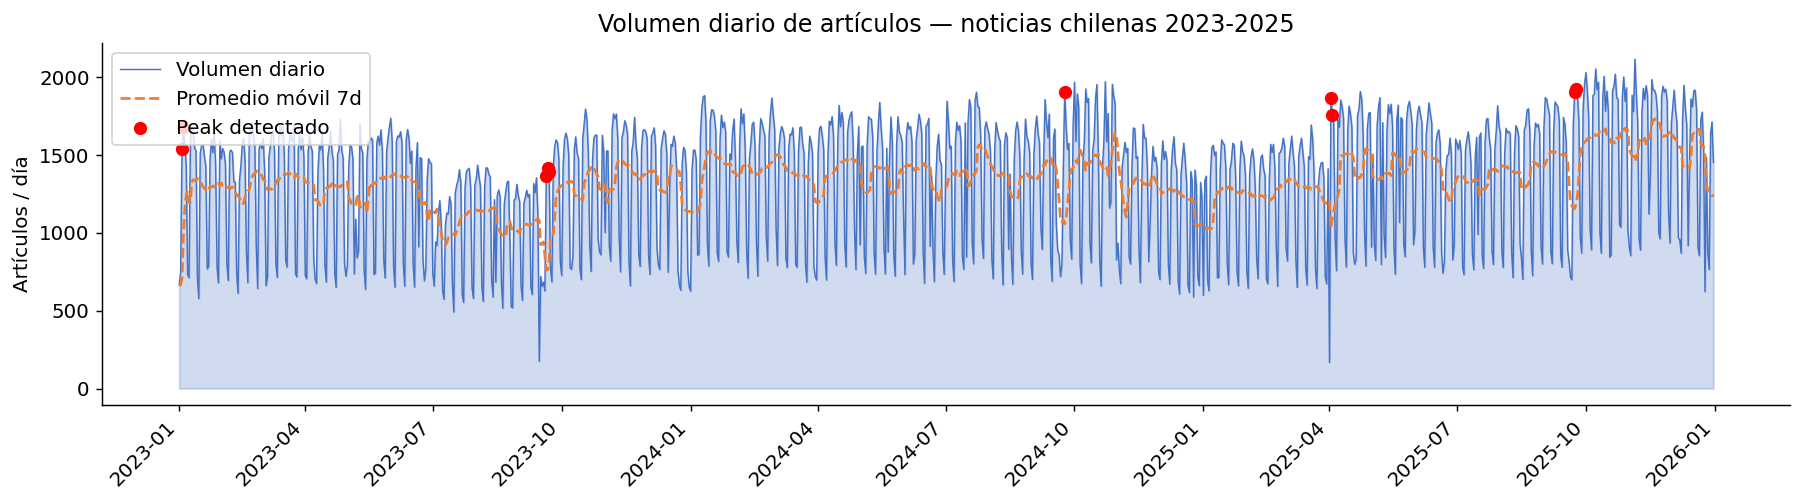

fig1_volumen_peaks.png guardada


In [39]:
# == Figura 1: Volumen diario + peaks ======================================
fig, ax = plt.subplots(figsize=(14, 4))

fechas_dt = [datetime.strptime(f, "%Y-%m-%d") for f in fechas_ordenadas]

ax.fill_between(fechas_dt, volumenes, alpha=0.25, color="#4472C4")
ax.plot(fechas_dt, volumenes, lw=0.8, color="#4472C4", label="Volumen diario")
ax.plot(fechas_dt, promedios, lw=1.5, color="#ED7D31", ls="--", label=f"Promedio móvil {VENTANA_DIAS}d")

# Marcar peaks
peaks_fechas = [datetime.strptime(p["fecha"], "%Y-%m-%d") for p in peaks[:10]]
peaks_vols   = [conteo_diario[p["fecha"]] for p in peaks[:10]]
ax.scatter(peaks_fechas, peaks_vols, color="#FF0000", zorder=5, s=40, label="Peak detectado")

ax.set_title("Volumen diario de artículos — noticias chilenas 2023-2025")
ax.set_ylabel("Artículos / día")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig("resultados/figuras/fig1_volumen_peaks.png", bbox_inches="tight")
plt.show()
print("fig1_volumen_peaks.png guardada")


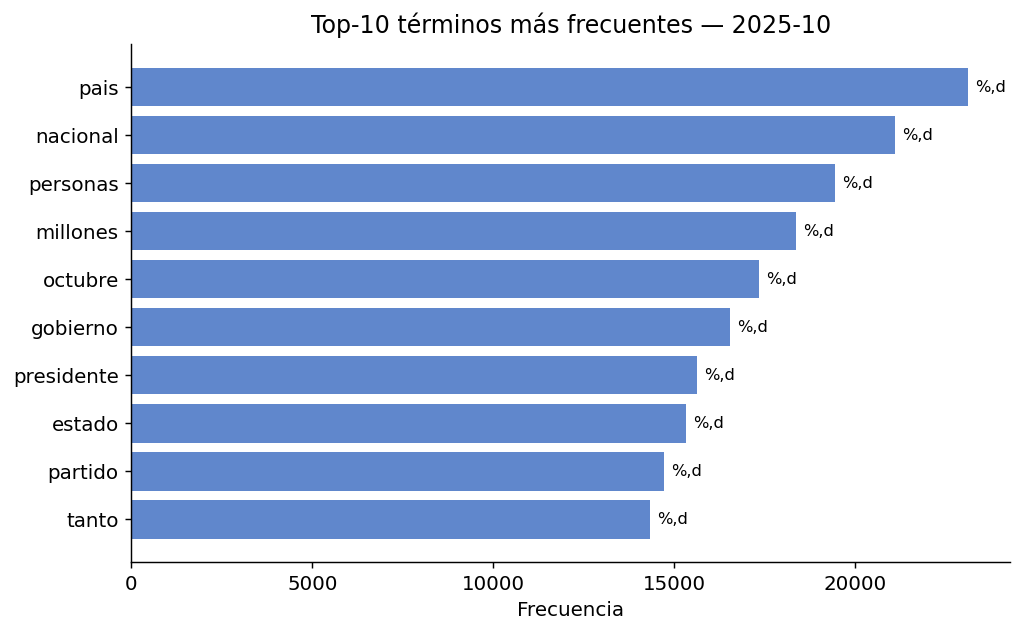

fig2_topk_mes.png guardada (2025-10)


In [40]:
# == Figura 2: Top-10 términos del mes más activo ==========================
mes_max = max(conteo_particiones, key=conteo_particiones.get)
top_mes = topk_mensual.get(mes_max, [])[:10]

if top_mes:
    palabras_bar = [t[0] for t in reversed(top_mes)]
    freqs_bar    = [t[1] for t in reversed(top_mes)]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(palabras_bar, freqs_bar, color="#4472C4", alpha=0.85)
    ax.bar_label(bars, fmt="%,d", padding=4, fontsize=9)
    ax.set_title(f"Top-10 términos más frecuentes — {mes_max}")
    ax.set_xlabel("Frecuencia")
    plt.tight_layout()
    plt.savefig("resultados/figuras/fig2_topk_mes.png", bbox_inches="tight")
    plt.show()
    print(f"fig2_topk_mes.png guardada ({mes_max})")


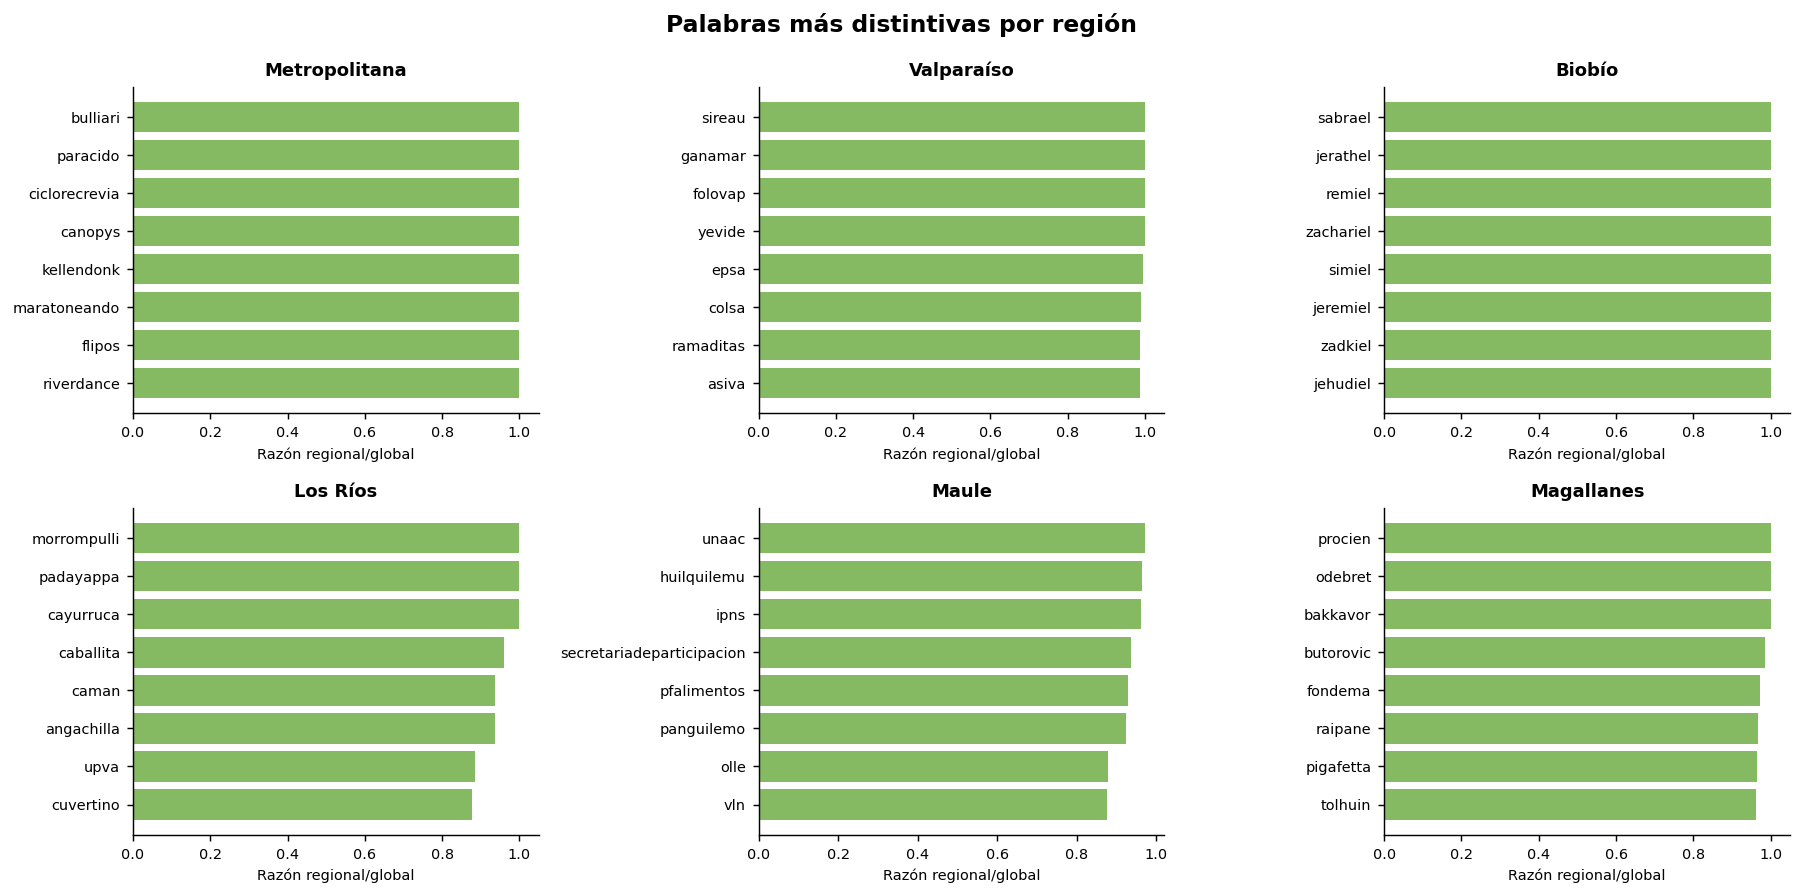

fig3_palabras_region.png guardada


In [41]:
# == Figura 3: Palabras más distintivas por región (top razón) =============
# Seleccionar top-3 palabras por región según razón regional/global
from collections import defaultdict

top_por_region = defaultdict(list)
for r in resultados_22:
    top_por_region[r["region"]].append((r["palabra"], r["razon"]))

# Tomar las 5 regiones con más artículos y sus top-3 palabras
regiones_plot = sorted(
    top_por_region.keys(),
    key=lambda rg: sum(rr["freq_regional"] for rr in resultados_22 if rr["region"] == rg),
    reverse=True
)[:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, region in zip(axes, regiones_plot):
    datos = sorted(top_por_region[region], key=lambda x: x[1], reverse=True)[:8]
    if not datos: continue
    pals = [d[0] for d in reversed(datos)]
    razones = [d[1] for d in reversed(datos)]
    bars = ax.barh(pals, razones, color="#70AD47", alpha=0.85)
    ax.set_title(region, fontsize=10, fontweight="bold")
    ax.set_xlabel("Razón regional/global", fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle("Palabras más distintivas por región", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("resultados/figuras/fig3_palabras_region.png", bbox_inches="tight")
plt.show()
print("fig3_palabras_region.png guardada")


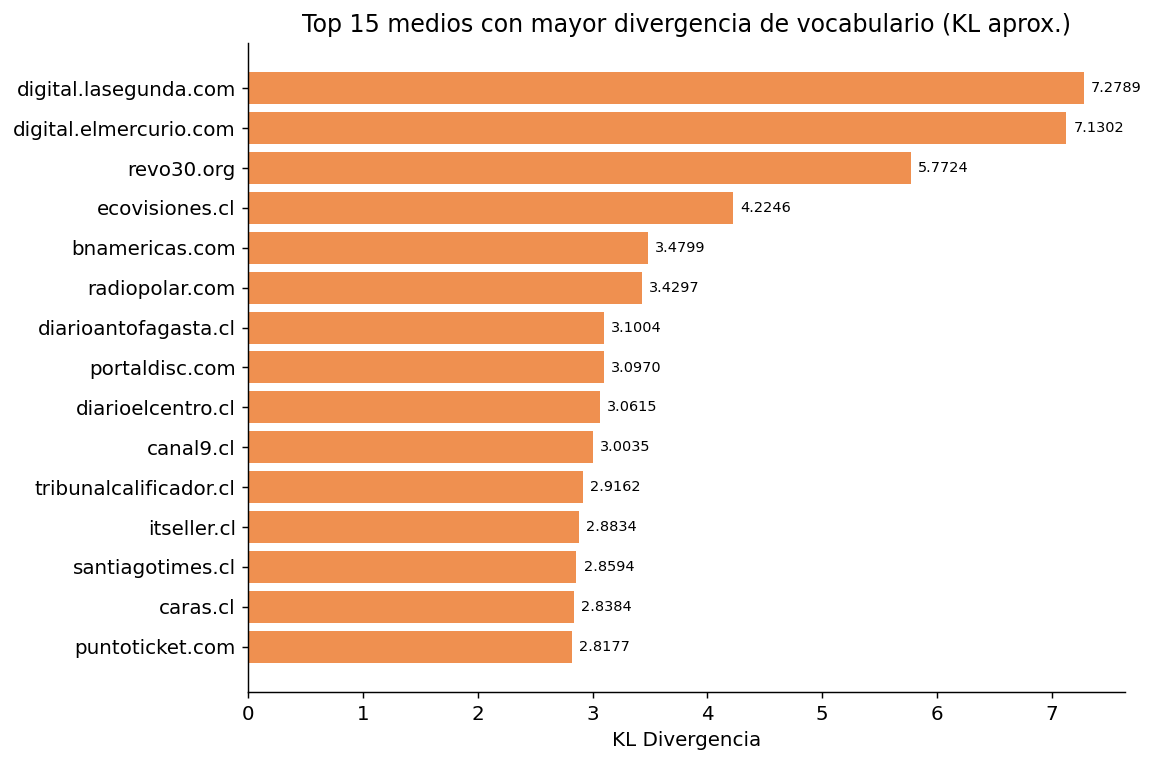

fig4_kl_fuentes.png guardada


In [42]:
# == Figura 4: Top-15 fuentes por divergencia KL ===========================
top_kl = kl_divergencias[:15]
fuentes_plot = [r["fuente"] for r in reversed(top_kl)]
kl_vals      = [r["kl_divergencia"] for r in reversed(top_kl)]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(fuentes_plot, kl_vals, color="#ED7D31", alpha=0.85)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=8)
ax.set_title("Top 15 medios con mayor divergencia de vocabulario (KL aprox.)")
ax.set_xlabel("KL Divergencia")
plt.tight_layout()
plt.savefig("resultados/figuras/fig4_kl_fuentes.png", bbox_inches="tight")
plt.show()
print("fig4_kl_fuentes.png guardada")
